# Foundations of Machine learning

Problem Set 3

Emily Fu

This file demonstrates conformal prediction with discrete and continuous outcome variables across two datasets. I start by importing my two datasets and spliting them into training sets, test sets, and calibration sets, which are used to calculate confidence intervals/sets. I define a significance value $\alpha$ for the prediction intervals, which governs unconditional coverage (the probability that your true value of the outcome variable in your test data is in the confidence set, $\text{P}(Y_{test} \in C(X_{test})) \geq 1 - \alpha$).

For the continuous outcome variable, point prediction (ridge regression with penalty parameter selected using cross-validation) yields the following conformity score: $s(X,y) = |y − \hat{f}(X)|$ where $\hat{f}(X)$ is the predicted value from the ridge regression model. I find the $(1 − \alpha)(n + 1)/n$-th quantile of the calibration conformity scores, where $n$ is the size of the calibration set mentioned above. Then, I construct prediction intervals $[\hat{f}(X) - \hat{q}, \hat{f}(X) + \hat{q}]$, where $\hat{q}$ is the respective quantile of the scores. 

Using quantile regression, I fit two separate models using the $\alpha / 2$ and $1 - \alpha / 2$ quantiles with corresponding conditional estimates $t_{\alpha / 2}(X)$ and $t_{1 - \alpha / 2}(x)$. The score is given by $s(X, y) = \max \ (t_{\alpha / 2}(X) − y, y − t_{1 - \alpha / 2}(X))$. Again, I find the $(1 − \alpha)(n + 1)/n$-th quantile of the scores and construct prediction intervals $[t_{\alpha / 2}(X) - \hat{q}, t_{1 - \alpha / 2}(X) + \hat{q}]$. I compare confidence bands calculated using scores from point prediction and quantile regression, discussing the differences between the two by plotting a subset of observations to show the true value, predicted value, and confidence bands of each point.

Next, I use penalised logistic regression and K-Nearest Neighbors classification, performing cross-validation on the training data to find the optimal penalty parameter and number of neighbours $k$ as in the first problemset, to implement conformal inference using the discrete outcome variable. My `evaluate_conformal_classifier` function implements conformal prediction by using the predicted probability of each possible label for each observation. This function finds $\hat{f}(y|X)$, which is the predicted probability of the observation belonging to $y$ given $X$. Then, I order each $y$ by this probability. 

The score is calculated as $s(X,y) = \sum_{y'} 1(j(y|X) \geq j(y'|x))f(y|X)$, where $1(\cdot)$ is the indicator function. This is a cumulative sum of probabilities for each class that is at least as likely as the true one. As with the continuous outcome variable, I find the $(1−\alpha)(n+1)/n$-th quantile of the calibration coformity scores. I find the prediction set by including all $y$ with scores within this range. Finally, I use the test set to calculate empirical coverage (how often the true $y$ is inside the prediction set), average set size (how large the prediction sets are), and conditional coverage (empirical coverage for each class separately), comparing these across the penalised logistic regression and K-Nearest-Neighbours results.


In [1]:
# importing packages

# display data
import pandas as pd

# train_test_split, GridSearchCV, KFold
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
# ridge regression, quantile regression, logistic regression
from sklearn.linear_model import Ridge, QuantileRegressor, LogisticRegression
# KNN
from sklearn.neighbors import KNeighborsClassifier
# standard scaler
from sklearn.preprocessing import StandardScaler
# pipeline
from sklearn.pipeline import Pipeline

import numpy as np

import matplotlib.pyplot as plt

# california housing dataset and wine dataset
from sklearn.datasets import fetch_california_housing, load_wine

In [2]:
# import data and set parameters

# random seed
seed = 420

# number of folds for cross-validation
k_folds = 5

# define possible penalties in ridge regression
param_grid_ridge = {'ridge__alpha': np.logspace(-4, 4, 50)}

# define possible penalties in quantile regression 
# would have used the same as param_grid_ridge but it takes too long
param_grid_qr = {'qr__alpha': np.logspace(-4, 1, 10)}

# define the parameter grid (possible values for n_neighbors)
param_grid_knn = {'knn__n_neighbors': np.arange(1, 25)}

# penalty parameter grid for logistic regression
param_grid_logistic = {'logistic__C': np.logspace(-4, 4, 50)}

# Split the dataset into three parts: a training set (60%) used for initial model fitting, 
# a calibration set (20%) used for conformal inference calibration, 
# and a test set (20%) used for final evaluation.

# load data
housing = fetch_california_housing()
wine = load_wine()
X_housing, y_housing = housing['data'], housing['target']
X_wine, y_wine = wine['data'], wine['target']

# training vs test/calibration data
X_housing_train, X_housing_temp, y_housing_train, y_housing_temp = train_test_split(
    X_housing, y_housing, test_size=0.40, random_state=seed, shuffle=True)
X_wine_train, X_wine_temp, y_wine_train, y_wine_temp = train_test_split(
    X_wine, y_wine, test_size=0.40, random_state=seed, shuffle=True)

# calibration data and test data
X_housing_cal, X_housing_test, y_housing_cal, y_housing_test = train_test_split(
    X_housing_temp, y_housing_temp, test_size=0.50, random_state=seed, shuffle=True)
X_wine_cal, X_wine_test, y_wine_cal, y_wine_test = train_test_split(
    X_wine_temp, y_wine_temp, test_size=0.50, random_state=seed, shuffle=True)

# subset_indices of points for plotting
n_plot = 50
subset_idx = np.random.choice(len(y_housing_test), size=n_plot, replace=False)

# store size of calibration set
n_housing_cal = len(X_housing_cal)

# confidence interval
alpha = 0.1

# quantiles for quantile regression
quantile_05 = alpha / 2
quantile_95 = 1 - alpha / 2

# significance level
sig_housing = (1 - alpha) * (n_housing_cal + 1) / n_housing_cal

In [3]:
# function to implement conformal inference for the classification problem
def evaluate_conformal_classifier(best_model, X_cal, y_cal, X_test, 
                                  y_test, alpha=0.1, model_name=''):
    # classes and class-to-column mapping
    classes = best_model.classes_
    class_to_col = {c: j for j, c in enumerate(classes)}

    '''calculate conformity scores:
    For a fixed x, the classifier outputs a probability distribution over possible y
    sort labels by predicted probability
    small rank = very likely label
    large rank = unlikely label
    define s(x,y) as the total probability mass of other y’ that are at least as likely as y'''

    # calibration conformity scores
    # For a fixed x, the classifier outputs a probability distribution over possible y
    probs_cal = best_model.predict_proba(X_cal)
    # sort labels by highest probability
    order_cal = np.argsort(-probs_cal, axis=1)                   
    probs_sorted_cal = np.take_along_axis(probs_cal, order_cal, axis=1)
    # cumulative sums of sorted probabilities
    cumsum_sorted_cal = np.cumsum(probs_sorted_cal, axis=1)

    # column index of true class for each calibration point
    true_col_cal = np.array([class_to_col[y] for y in y_cal])

    # position of true class in the sorted probabilities
    pos_cal = np.array([
        np.where(order_cal[i] == true_col_cal[i])[0][0]
        for i in range(len(y_cal))])
    # print(np.array([
    #     np.where(order_cal[i] == true_col_cal[i])[0][0]
    #     for i in range(len(y_cal))]))

    # conformity scores
    scores_cal = cumsum_sorted_cal[np.arange(len(y_cal)), pos_cal]

    # conformal quantile
    n_cal = len(X_cal)
    sig_cal = (1 - alpha) * (n_cal + 1) / n_cal

    # find the (1−alpha)(n+1)/n-th quantile of the calibration scores
    quantile = np.quantile(scores_cal, sig_cal)
    # print(f'{model_name} quantile: {quantile}')

    # test set conformity scores
    # for a fixed x, the classifier outputs a probability distribution over possible y
    probs_test = best_model.predict_proba(X_test)
    # print(probs_test)
    # sort labels by highest probability
    order_test = np.argsort(-probs_test, axis=1)
    # print(order_test)
    probs_sorted_test = np.take_along_axis(probs_test, order_test, axis=1)
    # print(probs_sorted_test)
    # cumulative sums of sorted probabilities
    cumsum_sorted_test = np.cumsum(probs_sorted_test, axis=1)
    # print(cumsum_sorted_test)

    # prediction set in sorted coordinates
    mask_sorted = cumsum_sorted_test <= quantile
    # print(mask_sorted)

    # map mask back to original class order
    mask = np.zeros_like(mask_sorted, dtype=bool)
    for i in range(mask.shape[0]):
        mask[i, order_test[i]] = mask_sorted[i]

    # print stuff for evaluation

    # fraction of test points where the true label is in the prediction set
    true_col_test = np.array([class_to_col[y] for y in y_test])

    # empirical coverage and average set size
    empirical_coverage = np.mean(mask[np.arange(len(y_test)), true_col_test])
    avg_set_size = mask.sum(axis=1).mean()

    # debugging
    # print(f'{model_name} quantile: {quantile}')
    # print('Unique calibration scores:', np.unique(scores_cal))
    # print('Top 10 sorted calibration scores:', np.sort(scores_cal)[-10:])

    print(f'{model_name}:')
    print(f'Empirical coverage: {empirical_coverage:.3f}')
    print(f'Average set size: {avg_set_size:.3f}')

    print('Coverage rate by true class:')
    for c in classes:
        idx = (y_test == c)
        cov_c = np.mean(mask[idx, class_to_col[c]])
        print(f'  Class {c}: {cov_c:.3f}')

## Continuous Outcome Regression: Ridge regression

In [ ]:
# scaling features and ridge regression with grid search
# normalising data todifferent contributions to the penalised terms
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())])
# grid search with 5-fold cross-validation
grid_ridge = GridSearchCV(estimator=pipe_ridge, param_grid=param_grid_ridge, cv=k_folds)

# Train your penalized linear regression model on the training set using the optimal 
# penalty_housing found using cross-validation.
grid_ridge.fit(X_housing_train, y_housing_train)

# For each point (X_i,y_i) in the calibration set, compute the conformity_housing score s(X_i,y_i).
best_model_ridge = grid_ridge.best_estimator_
y_housing_cal_pred_ridge = best_model_ridge.predict(X_housing_cal)
conformity_housing_scores_ridge = np.abs(y_housing_cal - y_housing_cal_pred_ridge)

# For a desired confidence level 1−alpha (e.g., alpha = 0.1 for 90% confidence), 
# find the (1−alpha)(n + 1)/n-th quantile of the calibration scores, 
# where n is the size of the calibration set.
quantile_ridge = np.quantile(conformity_housing_scores_ridge, sig_housing)

# For evaluation, construct prediction intervals [\hat{f}(X) - q, \hat{f}(X) + q] 
# where q is the appropriate quantile of calibration scores.
y_housing_test_pred_ridge = best_model_ridge.predict(X_housing_test)
lower_ridge = y_housing_test_pred_ridge - quantile_ridge
upper_ridge = y_housing_test_pred_ridge + quantile_ridge

# Compute empirical coverage on the test set, 
# when the true value falls within the prediction set
coverage_ridge = np.mean((y_housing_test >= lower_ridge) & (y_housing_test <= upper_ridge))
print(f'Empirical coverage on the test set: {coverage_ridge:.3f}')

# calculate average interval width, 
interval_widths_ridge = upper_ridge - lower_ridge
avg_interval_width_ridge = np.mean(interval_widths_ridge)
print(f'Average interval width: {avg_interval_width_ridge:.3f}')

Empirical coverage on the test set: 0.887
Average interval width: 2.090


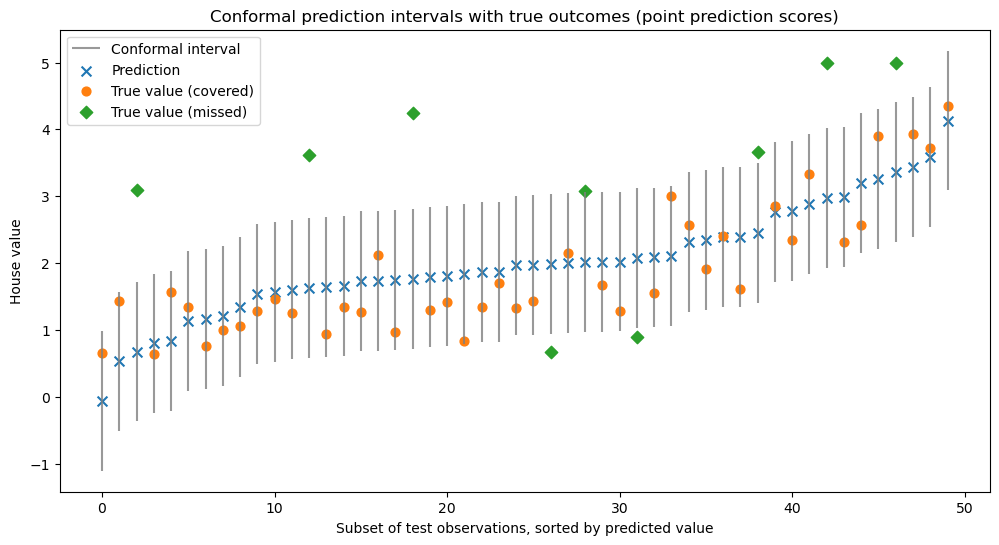

In [14]:
# and plot prediction intervals for a subset of test points compared with true values.

# extract values
y_true_sub = y_housing_test[subset_idx]
y_pred_sub = y_housing_test_pred_ridge[subset_idx]
lower_sub = lower_ridge[subset_idx]
upper_sub = upper_ridge[subset_idx]

# sort values by predicted value for visualisaiton
order = np.argsort(y_pred_sub)
y_true_sub = y_true_sub[order]
y_pred_sub = y_pred_sub[order]
lower_sub = lower_sub[order]
upper_sub = upper_sub[order]

x = np.arange(n_plot)

plt.figure(figsize=(12, 6))

# interval as vertical lines
plt.vlines(x, lower_sub, upper_sub, color='gray', alpha=0.8, label='Conformal interval')

# predicted value
plt.scatter(x, y_pred_sub, marker='x', s=50, label='Prediction')

# true value
covered = (y_true_sub >= lower_sub) & (y_true_sub <= upper_sub)
plt.scatter(x[covered], y_true_sub[covered], s=40, label='True value (covered)')
plt.scatter(x[~covered], y_true_sub[~covered], s=40, marker='D', label='True value (missed)')

plt.xlabel('Subset of test observations, sorted by predicted value')
plt.ylabel('House value')
plt.title('Conformal prediction intervals with true outcomes (point prediction scores)')
plt.legend(loc='upper left')
plt.show()

## Continuous Outcome Regression: Quantile regression

Using the same continuous outcome dataset from the previous problem, implement conformal inference with quantile regression. Fit quantile regression models for quantiles $\tau_{\alpha/2}$ and $\tau_{1−\alpha/2}$ (e.g., 0.05 and 0.95 for $\alpha = 0.1$). Let $t_{\alpha/2}$ and $t_{1−\alpha/2}$ be the predicted quantiles. Use the conformity score: $s(X,y) = \text{max} [t_{\alpha/2}(X) − y, y − t_{1−\alpha/2}(X)]$

In [4]:
# create quantile regression models for the two quantiles
qr_05 = Pipeline([('scaler', StandardScaler()),
                  ('qr', QuantileRegressor(quantile=quantile_05))])
qr_95 = Pipeline([('scaler', StandardScaler()),
                  ('qr', QuantileRegressor(quantile=quantile_95))])

# grid search with 5-fold cross-validation for both quantiles
grid_qr_05 = GridSearchCV(estimator=qr_05, param_grid=param_grid_qr, cv=k_folds)
grid_qr_95 = GridSearchCV(estimator=qr_95, param_grid=param_grid_qr, cv=k_folds)

# fit the models on the training data
grid_qr_05.fit(X_housing_train, y_housing_train)
grid_qr_95.fit(X_housing_train, y_housing_train)

# For each point (Xi,yi) in the calibration set, compute the conformity score s(Xi,yi).
best_qr_05 = grid_qr_05.best_estimator_
best_qr_95 = grid_qr_95.best_estimator_
t_05_cal = grid_qr_05.predict(X_housing_cal)
t_95_cal = grid_qr_95.predict(X_housing_cal)
conformity_housing_scores_qr = np.maximum(t_05_cal - y_housing_cal, y_housing_cal - t_95_cal)

# For a desired confidence level 1−alpha (e.g., alpha = 0.1 for 90% confidence), 
# find the (1−alpha)(n+ 1)/n-th quantile of the calibration scores, where n is the size of the calibration set.
quantile_qr = np.quantile(conformity_housing_scores_qr, sig_housing)

# quantile regression confidence bands
t_05_test = grid_qr_05.predict(X_housing_test)
t_95_test = grid_qr_95.predict(X_housing_test)
lower_qr = t_05_test - quantile_qr
upper_qr = t_95_test + quantile_qr

# Compute empirical coverage on the test set, 
coverage_qr = np.mean((y_housing_test >= lower_qr) & (y_housing_test <= upper_qr))
print(f'Empirical coverage on the test set: {coverage_qr:.3f}')

# calculate average interval width, 
interval_widths_qr = upper_qr - lower_qr
avg_interval_width_qr = np.mean(interval_widths_qr)
print(f'Average interval width: {avg_interval_width_qr:.3f}')

Empirical coverage on the test set: 0.890
Average interval width: 2.208


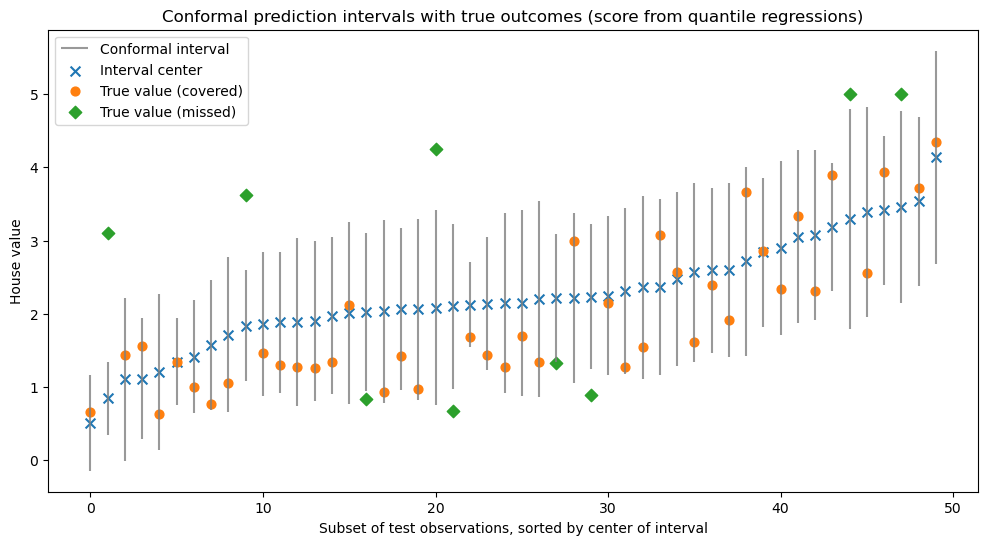

In [16]:
# and plot prediction intervals for a subset of test points compared with true values.

# extract values
y_true_sub = y_housing_test[subset_idx]
lower_sub = lower_qr[subset_idx]
upper_sub = upper_qr[subset_idx]
center_sub = 0.5 * (lower_sub + upper_sub)

# sort values by predicted value for visualisaiton
order = np.argsort(center_sub)
y_true_sub = y_true_sub[order]
lower_sub = lower_sub[order]
upper_sub = upper_sub[order]
center_sub = center_sub[order]

x = np.arange(n_plot)

plt.figure(figsize=(12, 6))
plt.vlines(x, lower_sub, upper_sub, color='gray', alpha=0.8, label='Conformal interval')
plt.scatter(x, center_sub, marker='x', s=50, label='Interval center')

covered = (y_true_sub >= lower_sub) & (y_true_sub <= upper_sub)
plt.scatter(x[covered], y_true_sub[covered], s=40, label='True value (covered)')
plt.scatter(x[~covered], y_true_sub[~covered], s=40, marker='D', label='True value (missed)')

plt.xlabel('Subset of test observations, sorted by center of interval')
plt.ylabel('House value')
plt.title('Conformal prediction intervals with true outcomes (score from quantile regressions)')
plt.legend(loc='upper left')
plt.show()

Like we saw in the lectures, the point prediction score yields conformal intervals of constant width and the quantile regression does not. The average interval width is slightly wider with the quantile regressions. The quantile regression confidence bands look (roughly) like they tend to get wider as the value of the target variable increases, which I think makes sense for our selection of target variable (median home price) because there's a lot more variation in home price at the upper end of the distribution, since there's more room for expensive homes to vary, while inexpensive homes have fewer characteristics available to differentiate them from other inexpensive homes. The true test values are mostly within the confidence bands, which is because we set $\alpha = 0.1$ and we have the coverage theorem that states the probability that the test outcome is in the confidence band is at least $1 - \alpha = 0.9$. In the sample, the empirical coverage for ridge regression scores and quantile scores are consistent with this guarantee, with empirical coverage on the test set being close to 0.9 for both. 

My subset of points doesn't happen to show this, but I can also see that the true values of the target variable has been top-coded at 5, and the top-coded observations have very widely varying predictions. For instance, a true top-coded value of 5 can correspond to a predicted value of anywhere between 1.5 and 7. I plotted residuals and predicted values below, where this corresponds to points that are roughly in a downward-sloping straight line, and the plot as a whole shows heteroskedasticity. This top-coding affects the conditional distribution $Y | X$, and conformal quantile regression grows or shrinks the distance between the quantiles to get coverage.

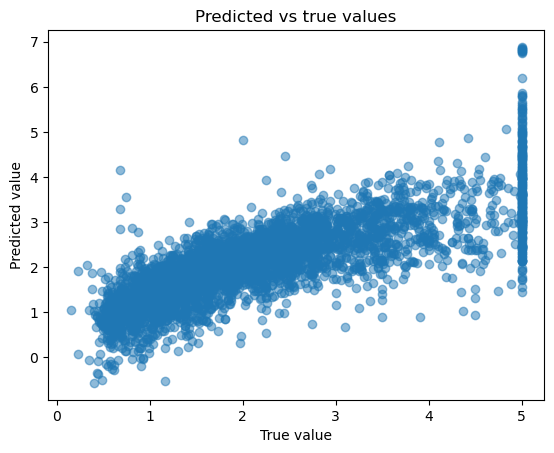

In [8]:
residuals = y_housing_test - y_housing_test_pred_ridge

plt.scatter(y_housing_test, y_housing_test_pred_ridge, alpha=0.5)
plt.xlabel('True value')
plt.ylabel('Predicted value')
plt.title('Predicted vs true values')
plt.show()

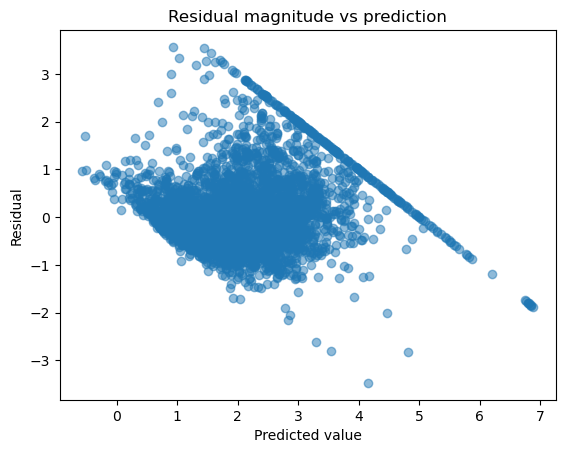

In [9]:
plt.scatter(y_housing_test_pred_ridge, residuals, alpha=0.5)
plt.xlabel('Predicted value')
plt.ylabel('Residual')
plt.title('Residual magnitude vs prediction')
plt.show()

## Discrete Classification: Logistic regression with L1 regularisation

In [10]:
# logistic regression with penalty
pipe_logistic = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(penalty='l1', solver='liblinear'))])

# grid search with 5-fold cross-validation for logistic regression
grid_logistic = GridSearchCV(estimator=pipe_logistic, param_grid=param_grid_logistic, cv=k_folds)
grid_logistic.fit(X_wine_train, y_wine_train)
best_model_logistic = grid_logistic.best_estimator_

evaluate_conformal_classifier(
    best_model_logistic,
    X_wine_cal, y_wine_cal,
    X_wine_test, y_wine_test,
    alpha=alpha,
    model_name='Logistic Regression')

Logistic Regression:
Empirical coverage: 0.944
Average set size: 1.194
Coverage rate by true class:
  Class 0: 0.933
  Class 1: 1.000
  Class 2: 0.875


In [11]:
# best penalty for logistic regression
print(f'Best penalty for logistic regression: {grid_logistic.best_params_['logistic__C']:.4f}')

Best penalty for logistic regression: 1.7575


## Discrete classification: K-Nearest Neighbours classification

In [12]:
# knn classifier
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())])

# grid search with 5-fold cross-validation for knn
grid_knn = GridSearchCV(estimator=pipe_knn, param_grid=param_grid_knn, cv=k_folds)
grid_knn.fit(X_wine_train, y_wine_train)
best_model_knn = grid_knn.best_estimator_

evaluate_conformal_classifier(
    best_model_knn,
    X_wine_cal, y_wine_cal,
    X_wine_test, y_wine_test,
    alpha=alpha,
    model_name='KNN')

KNN:
Empirical coverage: 1.000
Average set size: 3.000
Coverage rate by true class:
  Class 0: 1.000
  Class 1: 1.000
  Class 2: 1.000


In [13]:
# get accuracy of best knn model on test set
accuracy_knn = best_model_knn.score(X_wine_test, y_wine_test)
print(f'Accuracy of KNN on test set: {accuracy_knn:.3f}')

Accuracy of KNN on test set: 1.000


- Logistic regression: Coverage is not perfectly balanced across classes (which is expected because conformal prediction guarantees marginal, not conditional coverage) but is still close to $1 - \alpha$
- KNN: Every test observation’s true label was included in its prediction set but that's because every prediction set contains all classes and the efficiency is awful, unlike the logistic regression results that on average contain fewer than two classes. I think the KNN model is a perfect predictor so it will assign probabilities of one or zero to every class (such as $(1,0,0)$). Since classes are included from most to least likely until their cumulative conditional probability hits the quantile and most calibration scores are 1, the conformal quantile will also be 1 and then you can't distinguish between the predicted class with probability 1 and labels with probability 0. Every label will have cumulative probability less than or equal to 1, so the set size is the same as the number of classes.